<a href="https://colab.research.google.com/github/b181005/Cellpose-Image-Analysis/blob/main/cellposeAll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# set up


### 1. Configuration — Define Experiment Variables

In [79]:
# Section 1: Configuration
dir_path = "/content/drive/MyDrive/DATA/Chris/HM 11-03-26/HM 11-03-26/oprm/test 1"

# Use the exact prefix found in your filenames
vehicle = 'B+'
drug = 'B+M+'

expression_control = 'CH1'
experiment_output = 'CH4'

# Set to True to ignore old masks and generate new ones
overwrite_masks = False

### 2. Installation — Install Required Python Packages

In [2]:
%pip install cellpose matplotlib numpy imagecodecs --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.1 MB/s eta 0:00:00


### 3. Imports — Load Libraries & Verify GPU Access

In [45]:
 #single image plot test
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from cellpose import models, plot, io, core
import pandas as pd
import seaborn as sns
import os
import imagecodecs
from pathlib import Path
from natsort import natsorted
import imagecodecs
import tifffile

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime to one with GPU")

2026-03-31 20:28:22,464 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 20:28:22,465 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 20:28:22,466 [INFO] ** TORCH CUDA version installed and working. **


# Google Drive

### 4. Google Drive — Mount Drive & List Directories

In [29]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
!ls /content/drive/MyDrive/DATA/

Mounted at /content/drive
Chris  images


# 5. File Discovery — Locate & List TIFF Image Files

In [30]:
# 1. Define path with a default fallback
try:
    dir_path = dir_path
except NameError:
    dir_path = "/content/drive/MyDrive/DATA/images/Psychatg02_07112025"

dir_obj = Path(dir_path)

if not dir_obj.exists():
    raise FileNotFoundError(f"Directory not found: {dir_path}")

# 2. List the files
image_ext = ".tif"
all_files = list(dir_obj.rglob("*" + image_ext))
files = natsorted([f for f in all_files if "_masks" not in f.name and "_flows" not in f.name])

# 3. Check if files were found
if len(files) == 0:
    print(f"Warning: No {image_ext} files found in {dir_path}")
else:
    print(f"{len(files)} images found.")
    print(f"Success! Found {len(files)} total images across all subfolders.")
    # Show the first 3 paths to verify they are correct
    for f in files[:3]:
        print(f"Found: {f}")

38 images found.
Success! Found 38 total images across all subfolders.
Found: /content/drive/MyDrive/DATA/Chris/HM 11-03-26/HM 11-03-26/oprm/test 1/B+_M+_w1/W001/P00001/B+M+_W001_P00001_CH1.tif
Found: /content/drive/MyDrive/DATA/Chris/HM 11-03-26/HM 11-03-26/oprm/test 1/B+_M+_w1/W001/P00001/B+M+_W001_P00001_CH4.tif
Found: /content/drive/MyDrive/DATA/Chris/HM 11-03-26/HM 11-03-26/oprm/test 1/B+_M+_w1/W001/P00001/B+M+_W001_P00001_Overlay.tif


In [37]:
separated_files = { "Drug": [], "Veh": [] }

for f in files:
    # Check for the more specific 'Drug' name first
    if drug in f.name:
        separated_files["Drug"].append(f)
    # Then check for 'Vehicle'
    elif vehicle in f.name:
        separated_files["Veh"].append(f)

# Now print to verify
for condition, file_list in separated_files.items():
    # Filter for the primary channel
    primary = [f for f in file_list if f"_{expression_control}.tif" in f.name]

    print(f"✅ {condition}: Found {len(primary)} primary images")

    # Print the first 3 filenames as examples
    for f in primary[:3]:
        print(f"    - {f.name}")

    if len(primary) > 3:
        print(f"    ... and {len(primary) - 3} more.")
    print("-" * 30)

✅ Drug: Found 6 primary images
    - B+M+_W001_P00001_CH1.tif
    - B+M+_W001_P00002_CH1.tif
    - B+M+_W001_P00003_CH1.tif
    ... and 3 more.
------------------------------
✅ Veh: Found 6 primary images
    - B+_W001_P00001_CH1.tif
    - B+_W001_P00002_CH1.tif
    - B+_W001_P00003_CH1.tif
    ... and 3 more.
------------------------------


### 6. Core Analysis Function — Define `run_cell_analysis()`

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from cellpose import models, plot, io, core
import pandas as pd
import seaborn as sns
import os
import imagecodecs
from pathlib import Path
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime to one with GPU")

def run_cell_analysis(image_path, condition_label, primary_channel_tag, secondary_channel_tag):
    """
    Performs feature extraction using existing masks if available,
    otherwise runs Cellpose segmentation.
    """
    print(f"--- Analyzing: {os.path.basename(image_path)} ---")
    global rows
    global primary_id

    p = Path(image_path)
    # Construct path for the secondary channel image based on primary_channel_tag and secondary_channel_tag
    secondary_channel_path = p.with_name(p.name.replace(f"_{primary_channel_tag}.tif", f"_{secondary_channel_tag}.tif"))
    mask_path = p.with_name(p.stem + "_masks.tif")

    if not secondary_channel_path.exists():
        print(f"Skipping: Secondary channel ({secondary_channel_tag}) pair not found for {p.name}")
        return

    # Load Images
    primary_img = io.imread(str(p))
    secondary_img = io.imread(str(secondary_channel_path))

    # Check for existing masks
    if mask_path.exists() and not overwrite_masks:
        print(f"Using existing mask: {mask_path.name}")
        masks = io.imread(str(mask_path))
    else:
        if overwrite_masks and mask_path.exists():
            print(f"Overwriting existing mask: {mask_path.name}...")
        else:
            print("No mask found. Running Cellpose segmentation...")
        masks_output, flows, styles = model.eval([primary_img], diameter=30, channel_axis=None)
        masks = masks_output[0]

        tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
        print(f"Saved new mask to: {mask_path.name}")

    # Measure Properties
    props_primary = regionprops(masks, intensity_image=primary_img)
    props_secondary = regionprops(masks, intensity_image=secondary_img)

    file_name = p.stem

    for p_primary, p_secondary in zip(props_primary, props_secondary):
        rows.append({
            "file": file_name,
            "condition": condition_label,
            "cell_id": p_primary.label,
            "area_px": p_primary.area,
            f"mean_{primary_channel_tag.lower()}": p_primary.mean_intensity, # Dynamic key
            f"mean_{secondary_channel_tag.lower()}": p_secondary.mean_intensity # Dynamic key
        })
    primary_id += 1

2026-03-31 21:00:32,647 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 21:00:32,649 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 21:00:32,651 [INFO] ** TORCH CUDA version installed and working. **


### 10. Model Initialization & Analysis Run with Ratio Calculation

In [80]:
from cellpose import models, io, core
import pandas as pd
import numpy as np
import os
from pathlib import Path

# 1. Initialize the Cellpose model
model = models.CellposeModel(gpu=True)

# 2. Initialize data storage
rows = []
primary_id = 1

# 3. Define the cleanup helper inside the loop cell to ensure it is used
def get_scalar(val):
    # If it is an array/list (like [R, G, B]), take the max or a specific channel
    if isinstance(val, (list, np.ndarray)) and len(np.atleast_1d(val)) > 1:
        return np.max(val)
    return val

# The global variables expression_control and experiment_output are defined in the new config cell
# They are assumed to be available from previous execution.

# 4. Loop through every condition
for condition, file_list in separated_files.items():
    print(f"\nProcessing group: {condition}")
    # Filter files for the primary channel tag
    ch2_files = [f for f in file_list if f"_{expression_control}.tif" in f.name]

    for file_path in ch2_files:
        # Call run_cell_analysis with the new channel parameters
        run_cell_analysis(str(file_path), condition, expression_control, experiment_output)

# 5. Create and clean the DataFrame
df_combined = pd.DataFrame(rows)

if not df_combined.empty:
    # Apply scalar conversion to the intensity columns, using dynamic names
    df_combined[f'mean_{expression_control.lower()}'] = df_combined[f'mean_{expression_control.lower()}'].apply(get_scalar)
    df_combined[f'mean_{experiment_output.lower()}'] = df_combined[f'mean_{experiment_output.lower()}'].apply(get_scalar)

    # Recalculate ratio using dynamic names
    df_combined['ratio_647_gfp'] = df_combined[f'mean_{experiment_output.lower()}'] / (df_combined[f'mean_{expression_control.lower()}'] + 1e-9)

    print(f"\nDone! Total cells analyzed: {len(df_combined)}")
    display(df_combined.head())
else:
    print("No data collected.")

2026-03-31 21:01:05,768 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 21:01:05,769 [INFO] >>>> using GPU (CUDA)
2026-03-31 21:01:07,937 [INFO] >>>> loading model /root/.cellpose/models/cpsam

Processing group: Drug
--- Analyzing: B+M+_W001_P00001_CH1.tif ---
Using existing mask: B+M+_W001_P00001_CH1_masks.tif
--- Analyzing: B+M+_W001_P00002_CH1.tif ---
Using existing mask: B+M+_W001_P00002_CH1_masks.tif
--- Analyzing: B+M+_W001_P00003_CH1.tif ---
Using existing mask: B+M+_W001_P00003_CH1_masks.tif
--- Analyzing: B+M+_W001_P00004_CH1.tif ---
Using existing mask: B+M+_W001_P00004_CH1_masks.tif
--- Analyzing: B+M+_W001_P00005_CH1.tif ---
Using existing mask: B+M+_W001_P00005_CH1_masks.tif
--- Analyzing: B+M+_W001_P00006_CH1.tif ---
Using existing mask: B+M+_W001_P00006_CH1_masks.tif

Processing group: Veh
--- Analyzing: B+_W001_P00001_CH1.tif ---
Using existing mask: B+_W001_P00001_CH1_masks.tif
--- Analyzing: B+_W001_P00002_CH1.tif ---
Using existing mask: B+_W001_P00

,file,condition,cell_id,area_px,mean_ch1,mean_ch4,ratio_647_gfp
0,B+M+_W001_P00001_CH1,Drug,1,87.0,25.931034,5.505747,0.212323
1,B+M+_W001_P00001_CH1,Drug,2,123.0,35.089431,27.788618,0.791937
2,B+M+_W001_P00001_CH1,Drug,3,259.0,33.073359,19.706564,0.595844
3,B+M+_W001_P00001_CH1,Drug,4,160.0,27.575000,15.112500,0.548051
4,B+M+_W001_P00001_CH1,Drug,5,155.0,34.096774,15.406452,0.451845


### 12. Segmentation Preview — Visualize Masks on Primary Channel

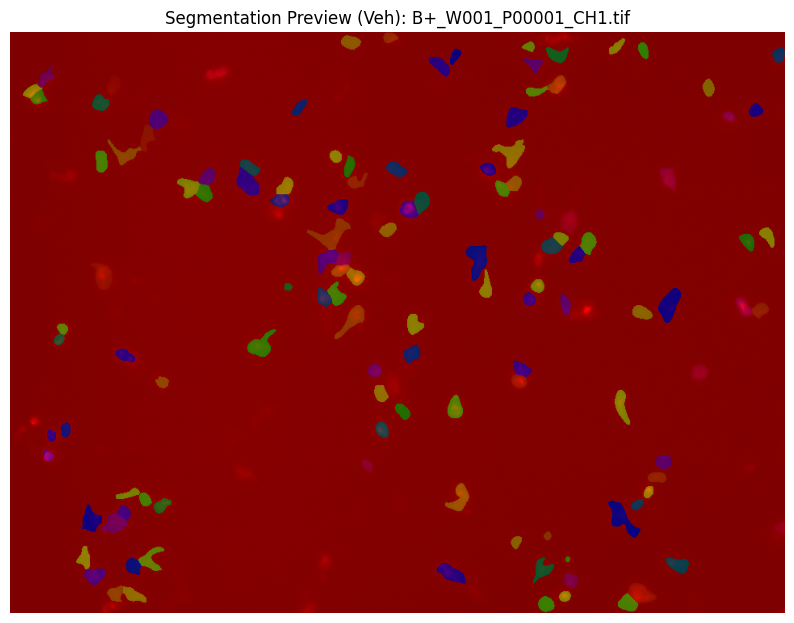

In [49]:
# Segmentation Preview
from cellpose import io, plot
import matplotlib.pyplot as plt
from pathlib import Path

preview_group = 'Veh'

if 'separated_files' in locals() and preview_group in separated_files:
    ch2_files = [f for f in separated_files[preview_group] if f'_{expression_control}.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))
        mask_path = test_file.with_name(test_file.stem + '_masks.tif')

        if mask_path.exists():
            masks = io.imread(str(mask_path))
            plt.figure(figsize=(10, 8))
            plt.imshow(img, cmap='gray')
            plt.imshow(masks, alpha=0.5, cmap='prism')
            plt.title(f'Segmentation Preview ({preview_group}): {test_file.name}')
            plt.axis('off')
            plt.show()
        else:
            print(f'Mask file not found at: {mask_path}')
else:
    print(f'Group {preview_group} not found in separated_files.')

### 13. Channel Intensity Preview — Inspect CH4 Images

File: B+_W001_P00001_CH4.tif
Shape: (720, 960, 3)
Max Intensity: 162
Min Intensity: 0


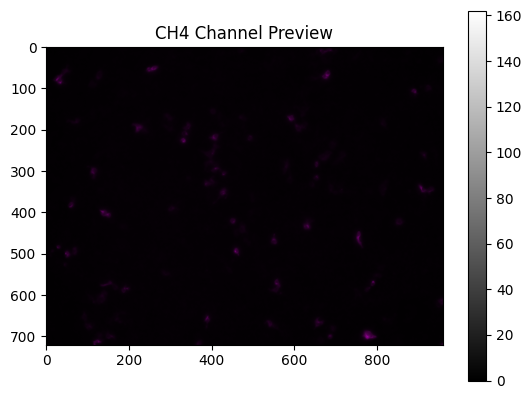

In [50]:
import matplotlib.pyplot as plt

# Let's check the first CH4 file found in the 'Control' group
# Assuming 'Veh' is the new 'Control' or a similar group for preview
if 'separated_files' in locals() and 'Veh' in separated_files:
    test_file_list = separated_files['Veh']
    ch4_test_file = None
    for f in test_file_list:
        # Look for a file that corresponds to the experiment_output channel
        if f'_{experiment_output}.tif' in f.name:
            ch4_test_file = f
            break

    if ch4_test_file:
        ch4_img_test = io.imread(str(ch4_test_file))
        print(f"File: {ch4_test_file.name}")
        print(f"Shape: {ch4_img_test.shape}")
        print(f"Max Intensity: {ch4_img_test.max()}")
        print(f"Min Intensity: {ch4_img_test.min()}")

        plt.imshow(ch4_img_test, cmap='gray')
        plt.title(f'{experiment_output} Channel Preview')
        plt.colorbar()
        plt.show()
    else:
        print(f"No {experiment_output} file found in 'Veh' group for preview.")
else:
    print("Group 'Veh' not found in separated_files.")

### 22. Quick DataFrame Snapshot

In [51]:
df = pd.DataFrame(rows)
df

,file,condition,cell_id,area_px,mean_ch1,mean_ch4
0,B+M+_W001_P00001_CH1,Drug,1,87.0,"[25.93103448275862, 0.0, 0.0]","[5.505747126436781, 0.0, 5.505747126436781]"
1,B+M+_W001_P00001_CH1,Drug,2,123.0,"[35.08943089430894, 0.0, 0.0]","[27.788617886178862, 0.0, 27.788617886178862]"
2,B+M+_W001_P00001_CH1,Drug,3,259.0,"[33.07335907335907, 0.0, 0.0]","[19.706563706563706, 0.0, 19.706563706563706]"
3,B+M+_W001_P00001_CH1,Drug,4,160.0,"[27.575, 0.0, 0.0]","[15.1125, 0.0, 15.1125]"
4,B+M+_W001_P00001_CH1,Drug,5,155.0,"[34.096774193548384, 0.0, 0.0]","[15.406451612903226, 0.0, 15.406451612903226]"
...,...,...,...,...,...,...
2863,B+_W001_P00006_CH1,Veh,149,186.0,"[12.591397849462366, 0.0, 0.0]","[4.903225806451613, 0.0, 4.903225806451613]"
2864,B+_W001_P00006_CH1,Veh,150,410.0,"[32.326829268292684, 0.0, 0.0]","[9.607317073170732, 0.0, 9.607317073170732]"
2865,B+_W001_P00006_CH1,Veh,151,220.0,"[26.004545454545454, 0.0, 0.0]","[5.495454545454545, 0.0, 5.495454545454545]"
2866,B+_W001_P00006_CH1,Veh,152,113.0,"[34.92035398230089, 0.0, 0.0]","[12.123893805309734, 0.0, 12.123893805309734]"


# 24. Visualization — Violin Plot: Signal Ratio by Condition

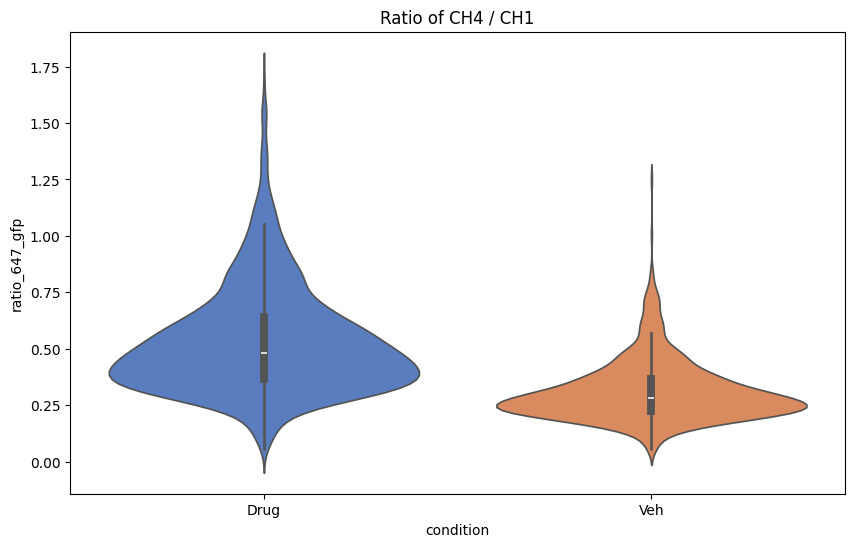

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# The x-axis and hue already use the 'condition' column
# which contains your 'B+' and 'B+M+' labels.
sns.violinplot(
    data=df_combined,
    x='condition',
    y='ratio_647_gfp',
    hue='condition',
    legend=False,
    palette='muted'
)

# Dynamic title using your variables from Section 1
plt.title(f'Ratio of {experiment_output} / {expression_control}')

plt.show()

### 28. Visualization — Scatter Plot: CH1 vs CH4 Intensity per Cell

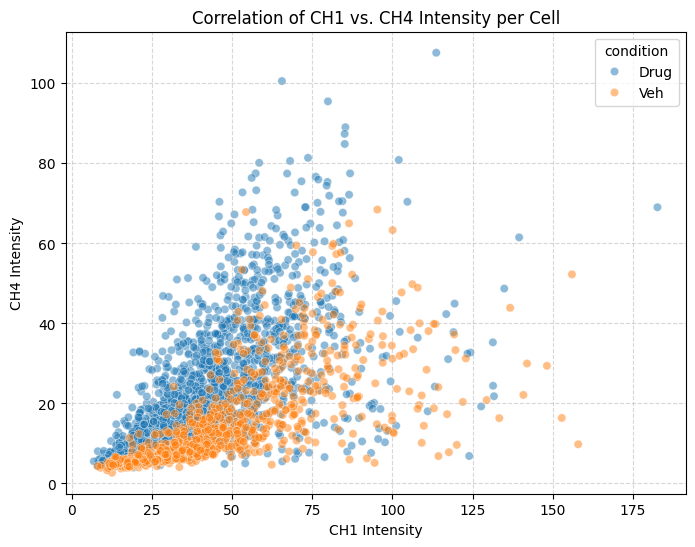

In [64]:
col_x = f'mean_{expression_control.lower()}'
col_y = f'mean_{experiment_output.lower()}'

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_combined,
    x=col_x,
    y=col_y,
    hue='condition',
    alpha=0.5
)
plt.xlabel(f"{expression_control} Intensity")
plt.ylabel(f"{experiment_output} Intensity")
plt.title(f"Correlation of {expression_control} vs. {experiment_output} Intensity per Cell")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

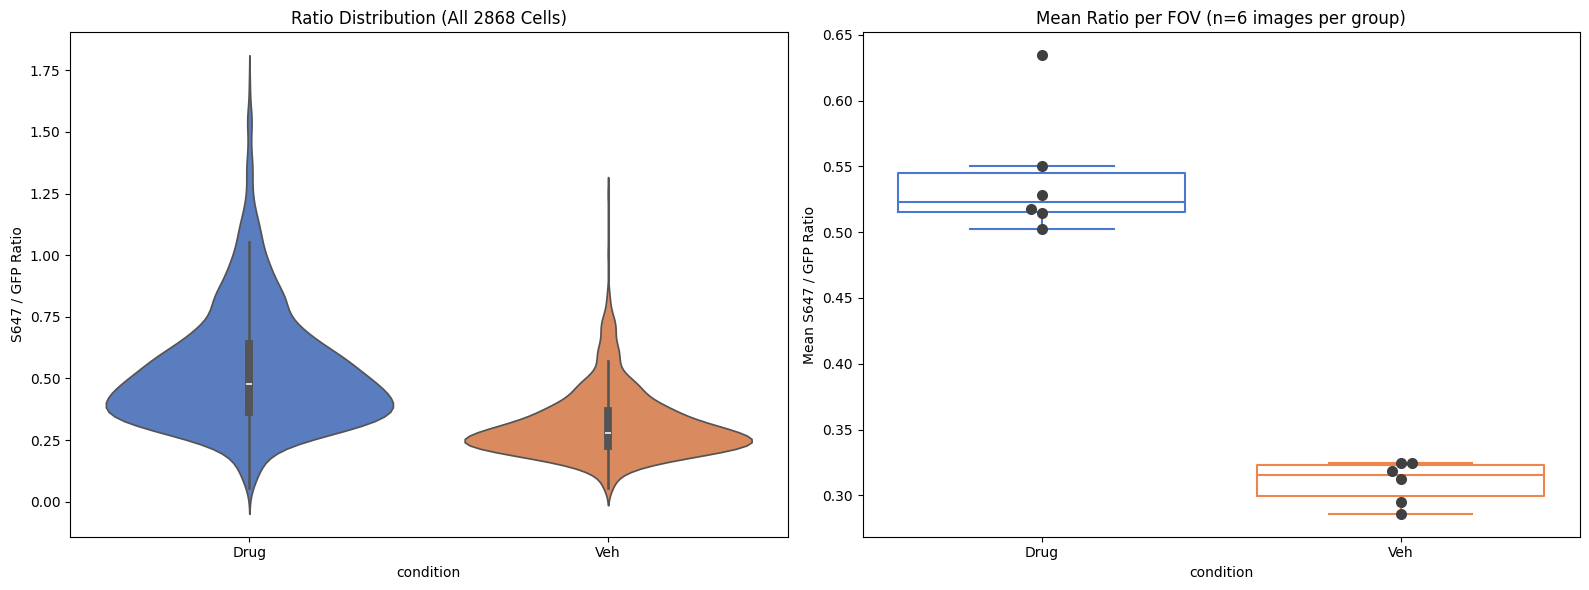

📋 Statistical Summary of Ratios:
           count    mean     std
condition                       
Drug         6.0  0.5412  0.0484
Veh          6.0  0.3102  0.0162


In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the average ratio for each individual FOV (Image)
fov_means = df_combined.groupby(['condition', 'file'])['ratio_647_gfp'].mean().reset_index()

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: All Individual Cells ---
sns.violinplot(data=df_combined, x='condition', y='ratio_647_gfp', hue='condition',
               palette='muted', ax=ax1, legend=False)
ax1.set_title(f'Ratio Distribution (All {len(df_combined)} Cells)')
ax1.set_ylabel('S647 / GFP Ratio')

# --- Plot 2: Average Ratio per FOV (Field of View) ---
sns.boxplot(data=fov_means, x='condition', y='ratio_647_gfp', hue='condition',
            palette='muted', fill=False, ax=ax2)
sns.swarmplot(data=fov_means, x='condition', y='ratio_647_gfp', color="0.25", size=8, ax=ax2)
ax2.set_title(f'Mean Ratio per FOV (n=6 images per group)')
ax2.set_ylabel('Mean S647 / GFP Ratio')

plt.tight_layout()
plt.show()

# Print the final numerical comparison
print("📋 Statistical Summary of Ratios:")
print(fov_means.groupby('condition')['ratio_647_gfp'].describe()[['count', 'mean', 'std']].round(4))

### 29. Segmentation Preview — Overlay Masks on Image

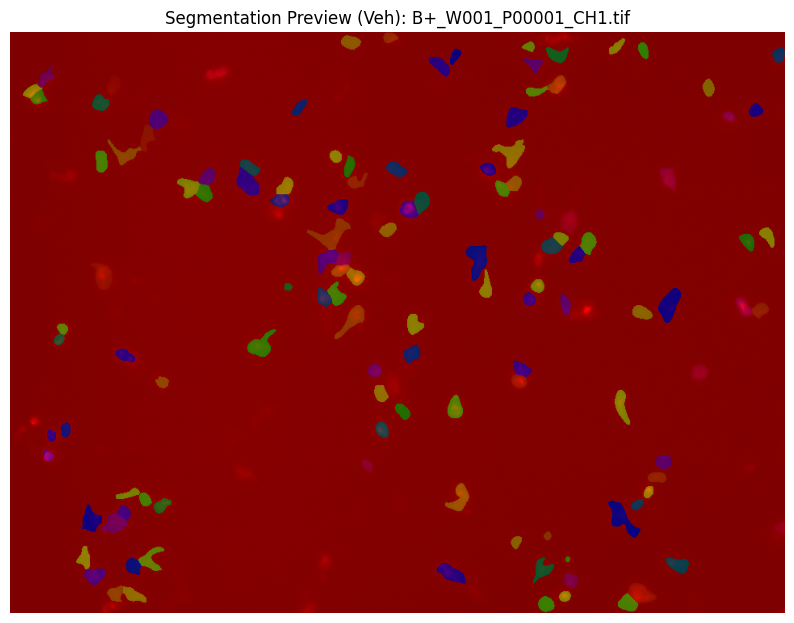

In [66]:
from cellpose import io, plot
import matplotlib.pyplot as plt
from pathlib import Path

preview_group = 'Veh'

if 'separated_files' in locals() and preview_group in separated_files:
    ch2_files = [f for f in separated_files[preview_group] if f'_{expression_control}.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))
        mask_path = test_file.with_name(test_file.stem + '_masks.tif')

        if mask_path.exists():
            masks = io.imread(str(mask_path))
            plt.figure(figsize=(10, 8))
            plt.imshow(img, cmap='gray')
            plt.imshow(masks, alpha=0.5, cmap='prism')
            plt.title(f'Segmentation Preview ({preview_group}): {test_file.name}')
            plt.axis('off')
            plt.show()
        else:
            print(f'Mask file not found at: {mask_path}')
else:
    print(f'Group {preview_group} not found in separated_files.')

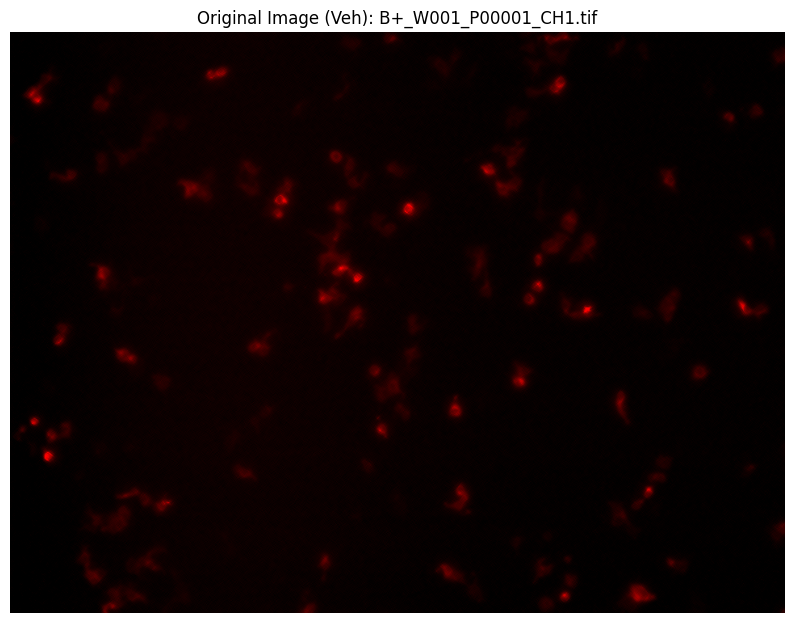

In [67]:
# Original Image Preview (No Masks)
if 'separated_files' in locals() and preview_group in separated_files:
    ch2_files = [f for f in separated_files[preview_group] if f'_{expression_control}.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))

        plt.figure(figsize=(10, 8))
        # Displaying with 'gray' colormap to show the raw GFP/Control signal
        plt.imshow(img, cmap='gray')

        plt.title(f'Original Image ({preview_group}): {test_file.name}')
        plt.axis('off')
        plt.show()
    else:
        print(f"No {expression_control} files found for group {preview_group}")

# Save Plots for AI


### 31. Export Options — Save Figures as Vector Files (Commented Out)

In [68]:
# import matplotlib.pyplot as plt

# plt.plot([1, 2, 3], [4, 5, 6])
# plt.savefig("figure.svg")   # SVG vector
# plt.savefig("figure.pdf")   # PDF vector
# plt.savefig("figure.eps")   # EPS vector


### 32. Dimensionality Reduction — PCA of Cell Features

In [74]:
# from sklearn.decomposition import PCA
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Use dynamic names to match your actual DataFrame columns
# col_control = f'mean_{expression_control.lower()}'
# col_output = f'mean_{experiment_output.lower()}'

# # 1. Define the numeric columns correctly
# numeric_cols = ['area_px', col_control, col_output, 'ratio_647_gfp']

# # 2. Filter data: Ensure we only use rows with valid numbers
# pca_data = df_combined.dropna(subset=numeric_cols)

# if not pca_data.empty:
#     # 3. Run PCA
#     pca = PCA(n_components=2)
#     X_pca = pca.fit_transform(pca_data[numeric_cols])

#     # 4. Plotting
#     plt.figure(figsize=(10, 7))
#     sns.scatterplot(
#         x=X_pca[:, 0],
#         y=X_pca[:, 1],
#         hue=pca_data['condition'],
#         alpha=0.6,
#         palette='viridis' # Changed to a standard palette that handles multiple groups well
#     )

#     plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
#     plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
#     plt.title(f"PCA of Cell Features: {drug} vs {vehicle}")
#     plt.grid(True, linestyle='--', alpha=0.3)
#     plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.show()
# else:
#     print('Insufficient data for PCA. Check if your columns match: ', df_combined.columns.tolist())